## Модель без циклов но с перебором параметров

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pandas.plotting as pd_plt
import matplotlib.colors as plt_colors
from IPython.display import display
import sklearn
from sklearn.datasets import load_iris

print("версия pandas:", pd.__version__)
print("версия sklearn:", sklearn.__version__)

версия pandas: 2.2.3
версия sklearn: 1.6.1


Загрузка датасета

In [2]:
iris_dataset=load_iris()

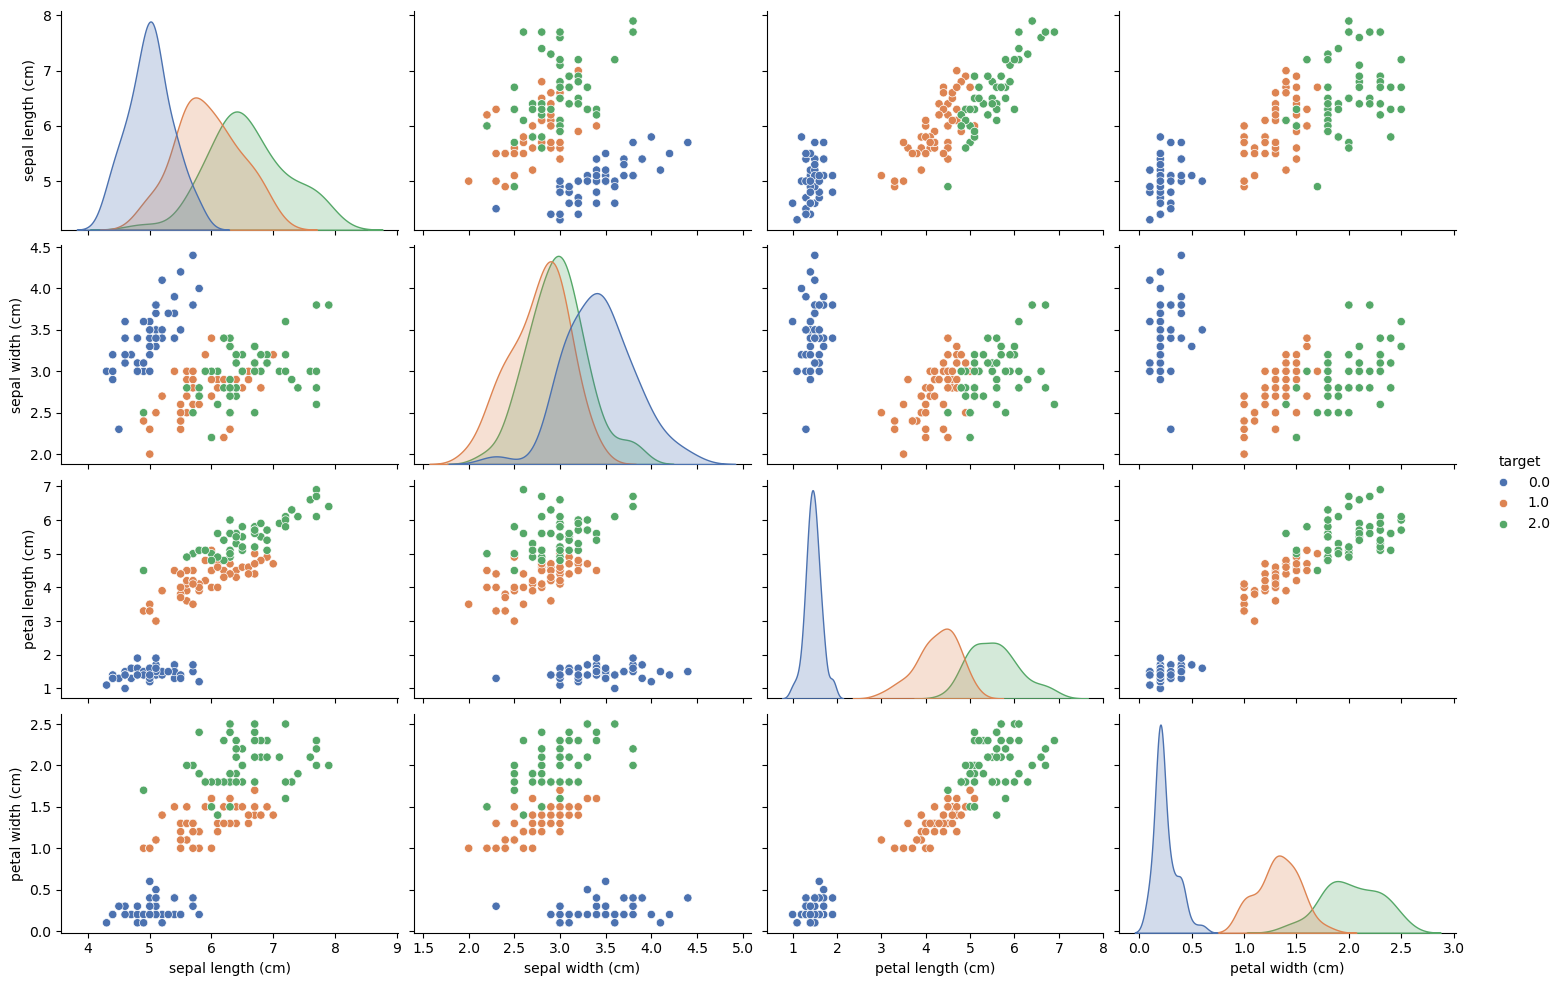

In [3]:
val = np.concatenate((iris_dataset['data'],iris_dataset['target'].reshape(-1,1)), axis=1)
col = iris_dataset['feature_names']+['target']
df = pd.DataFrame(val, columns = col)

sns.pairplot(df, hue='target', palette="deep", aspect=1.5);  

## Делим набор на тренировочный и тестовый
Желательно при классификации использовать стратификацию

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(iris_dataset['data'],iris_dataset['target'],
                                               stratify =iris_dataset['target'], random_state=42)

In [5]:
print('X_train',X_train.shape)
print('y_train',y_train.shape)

X_train (112, 4)
y_train (112,)


In [6]:
print('X_test',X_test.shape)
print('y_test',y_test.shape)

X_test (38, 4)
y_test (38,)


In [7]:
y_train

array([2, 2, 1, 1, 1, 2, 0, 2, 0, 2, 0, 2, 1, 0, 0, 1, 2, 0, 0, 1, 1, 1,
       0, 1, 2, 0, 2, 1, 2, 0, 0, 1, 0, 2, 0, 0, 1, 0, 1, 0, 0, 1, 2, 2,
       0, 2, 1, 0, 2, 0, 2, 2, 0, 1, 2, 2, 1, 1, 0, 1, 1, 2, 1, 2, 0, 1,
       0, 2, 1, 2, 1, 2, 2, 0, 2, 1, 0, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 2,
       2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 0, 0, 0,
       1, 0])

In [8]:
y_test

array([0, 1, 1, 1, 0, 1, 2, 2, 2, 2, 2, 2, 1, 1, 0, 0, 0, 1, 0, 1, 2, 1,
       2, 1, 2, 1, 0, 2, 0, 1, 2, 2, 0, 0, 0, 0, 2, 1])

### Обучение с настройками по умолчанию

In [9]:
from sklearn.neighbors import KNeighborsClassifier
X_train,X_test,y_train,y_test=train_test_split(iris_dataset['data'],iris_dataset['target'],
                                               stratify =iris_dataset['target'], random_state=12)
knk = KNeighborsClassifier()
knk.fit(X_train,y_train)

KNeighborsClassifier()

In [10]:
from sklearn.metrics import accuracy_score
y_pred_train = knk.predict(X_train)
y_pred_test = knk.predict(X_test)

print("Значения правильности на тренировочном наборе:", accuracy_score(y_train, y_pred_train))
print("Значения правильности на тестовом наборе:     ",accuracy_score(y_test, y_pred_test))

Значения правильности на тренировочном наборе: 0.9910714285714286
Значения правильности на тестовом наборе:      0.9473684210526315


### Кросс-валидация

Значения правильности перекрестной проверки: [1.   0.95 1.   0.89 0.95 0.95 1.   1.  ]


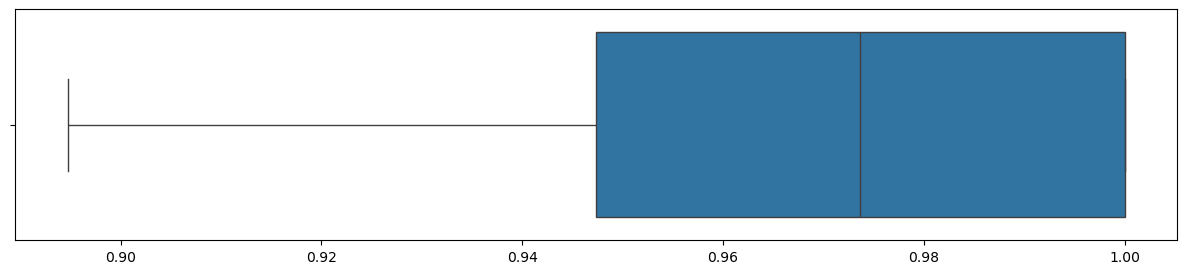

In [11]:
from sklearn.model_selection import cross_val_score 


knk = KNeighborsClassifier()
cross_vall = cross_val_score(knk, iris_dataset.data, iris_dataset.target, cv=8)

np.set_printoptions(precision=2)
print("Значения правильности перекрестной проверки:",cross_vall)

plt.figure(figsize=(15,3))
ax = sns.boxplot(x=cross_vall);

### Пербор параметров алгоритма
Цель найти наилучшею комбинацию

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = [{
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 15, 16, 17, 20],
    'p': [1, 2, 3, 4, 5]
}]

grid = GridSearchCV(knk, param_grid, cv = 8)
grid.fit(X_train, y_train)

GridSearchCV(cv=8, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14,
                                          15, 16, 17, 20],
                          'p': [1, 2, 3, 4, 5]}])

In [13]:
grid_result = pd.DataFrame(grid.cv_results_).sort_values(["rank_test_score",'std_test_score']).T
grid_result

,18,19,22,23,24,28,29,32,33,34,...,64,66,67,68,72,73,78,76,77,79
mean_fit_time,0.000596,0.000593,0.000566,0.000578,0.0006,0.000636,0.000681,0.000635,0.000666,0.000636,...,0.000544,0.000535,0.000545,0.00054,0.000572,0.000551,0.000648,0.000691,0.000889,0.000822
std_fit_time,0.000036,0.00002,0.000017,0.00001,0.000031,0.000056,0.000058,0.000063,0.0001,0.000043,...,0.000013,0.000012,0.000013,0.000008,0.000051,0.000019,0.000055,0.000176,0.000187,0.000257
mean_score_time,0.001959,0.002009,0.001948,0.001971,0.002107,0.002112,0.002618,0.002096,0.002433,0.002138,...,0.001869,0.001793,0.00193,0.001848,0.001883,0.001906,0.002387,0.002457,0.002738,0.00243
std_score_time,0.000049,0.000056,0.000062,0.000079,0.00019,0.000079,0.000651,0.000075,0.000447,0.000103,...,0.000087,0.000038,0.000108,0.000026,0.000049,0.000066,0.000198,0.000547,0.000364,0.000353
param_n_neighbors,4,4,5,5,5,6,6,7,7,7,...,15,16,16,16,17,17,20,20,20,20
param_p,4,5,3,4,5,4,5,3,4,5,...,5,2,3,4,3,4,4,2,3,5
params,"{'n_neighbors': 4, 'p': 4}","{'n_neighbors': 4, 'p': 5}","{'n_neighbors': 5, 'p': 3}","{'n_neighbors': 5, 'p': 4}","{'n_neighbors': 5, 'p': 5}","{'n_neighbors': 6, 'p': 4}","{'n_neighbors': 6, 'p': 5}","{'n_neighbors': 7, 'p': 3}","{'n_neighbors': 7, 'p': 4}","{'n_neighbors': 7, 'p': 5}",...,"{'n_neighbors': 15, 'p': 5}","{'n_neighbors': 16, 'p': 2}","{'n_neighbors': 16, 'p': 3}","{'n_neighbors': 16, 'p': 4}","{'n_neighbors': 17, 'p': 3}","{'n_neighbors': 17, 'p': 4}","{'n_neighbors': 20, 'p': 4}","{'n_neighbors': 20, 'p': 2}","{'n_neighbors': 20, 'p': 3}","{'n_neighbors': 20, 'p': 5}"
split0_test_score,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.928571,0.928571,0.928571,0.928571,0.928571,0.928571,0.928571,0.928571,0.928571,0.928571
split1_test_score,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.928571,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
split2_test_score,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.928571,0.928571,0.928571,0.928571,0.928571,0.928571,0.928571,0.928571,0.928571


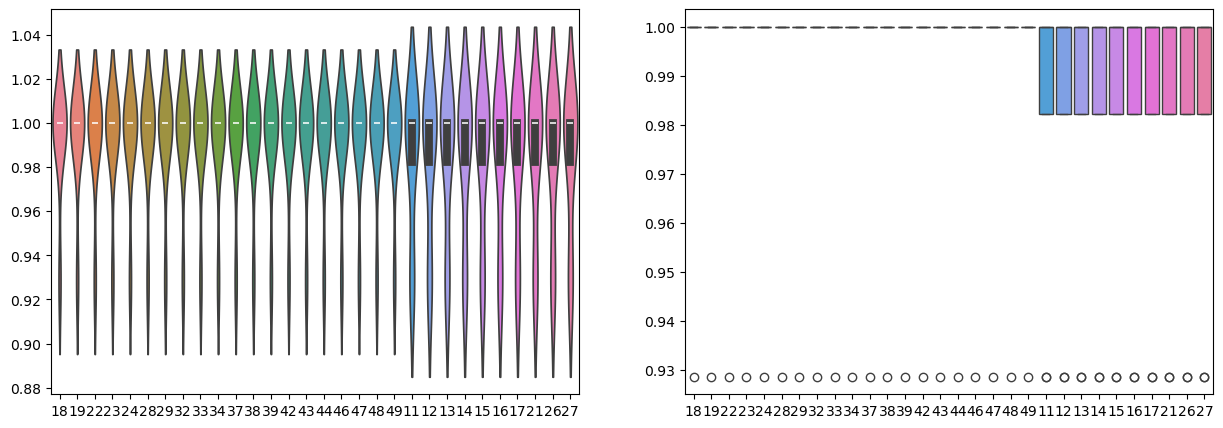

In [14]:
mask = grid_result.index[grid_result.index.str.endswith("_test_score")][:-3]
tabl = grid_result.loc[mask].iloc[:,:30]
#########################
tabl.columns = tabl.columns.astype(str) # ВНИМАНИЕ ЭТО ОЧЕНЬ ВАЖНО !!!
#########################
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
sns.violinplot(data=tabl,    ax=ax1);
sns.boxplot(data=tabl, ax=ax2);

In [15]:
grid.best_estimator_

KNeighborsClassifier(n_neighbors=4, p=4)

In [16]:
knk = KNeighborsClassifier(n_neighbors=4, p=4)
knk.fit(X_train,y_train)

y_pred_train = knk.predict(X_train)
y_pred_test = knk.predict(X_test)

print("Значения правильности на тренировочном наборе:", accuracy_score(y_train, y_pred_train))
print("Значения правильности на тестовом наборе:     ",accuracy_score(y_test, y_pred_test))

Значения правильности на тренировочном наборе: 0.9910714285714286
Значения правильности на тестовом наборе:      0.9210526315789473


In [17]:
knk = KNeighborsClassifier(n_neighbors=5, p=4)
knk.fit(X_train,y_train)

y_pred_train = knk.predict(X_train)
y_pred_test = knk.predict(X_test)

print("Значения правильности на тренировочном наборе:", accuracy_score(y_train, y_pred_train))
print("Значения правильности на тестовом наборе:     ",accuracy_score(y_test, y_pred_test))

Значения правильности на тренировочном наборе: 0.9910714285714286
Значения правильности на тестовом наборе:      0.9473684210526315
